In [1]:
import numpy as np

import scipy.stats as stats
from scipy.special import rel_entr
from scipy.integrate import quad

import matplotlib.pyplot as plt

import time

In [ ]:
class Distribution(stats.rv_continuous):
    def _pdf(self, x):
        return 4 * (np.log(x)) ** 3 / x

    def _cdf(self, x):
        return (np.log(x)) ** 4

    def _ppf(self, q):
        return np.exp(q**0.25)

    def _get_support(self):
        return 1, np.e


M = 4 * (np.e - 1) / np.e

In [3]:
n_values = np.logspace(1, 5, 20).astype(int)
distr = Distribution(a=1, b=np.e)

In [ ]:
times1 = []
samples1 = []
for n in n_values:
    t = time.time()
    samples = distr.rvs(size=n)
    times1.append(time.time() - t)
    samples1.extend(samples)

times2 = []
samples2 = []
for n in n_values:
    t = time.time()
    samples = distr.ppf(np.random.uniform(0, 1, n))
    times2.append(time.time() - t)
    samples2.extend(samples)

times3 = []
samples3 = []
for n in n_values:
    t = time.time()
    samples = []
    while len(samples) < n:
        x = np.random.uniform(1, np.e)
        if np.random.rand() <= np.log(x) ** 3 * np.e / x:
            samples.append(x)
    times3.append(time.time() - t)
    samples3.extend(samples)

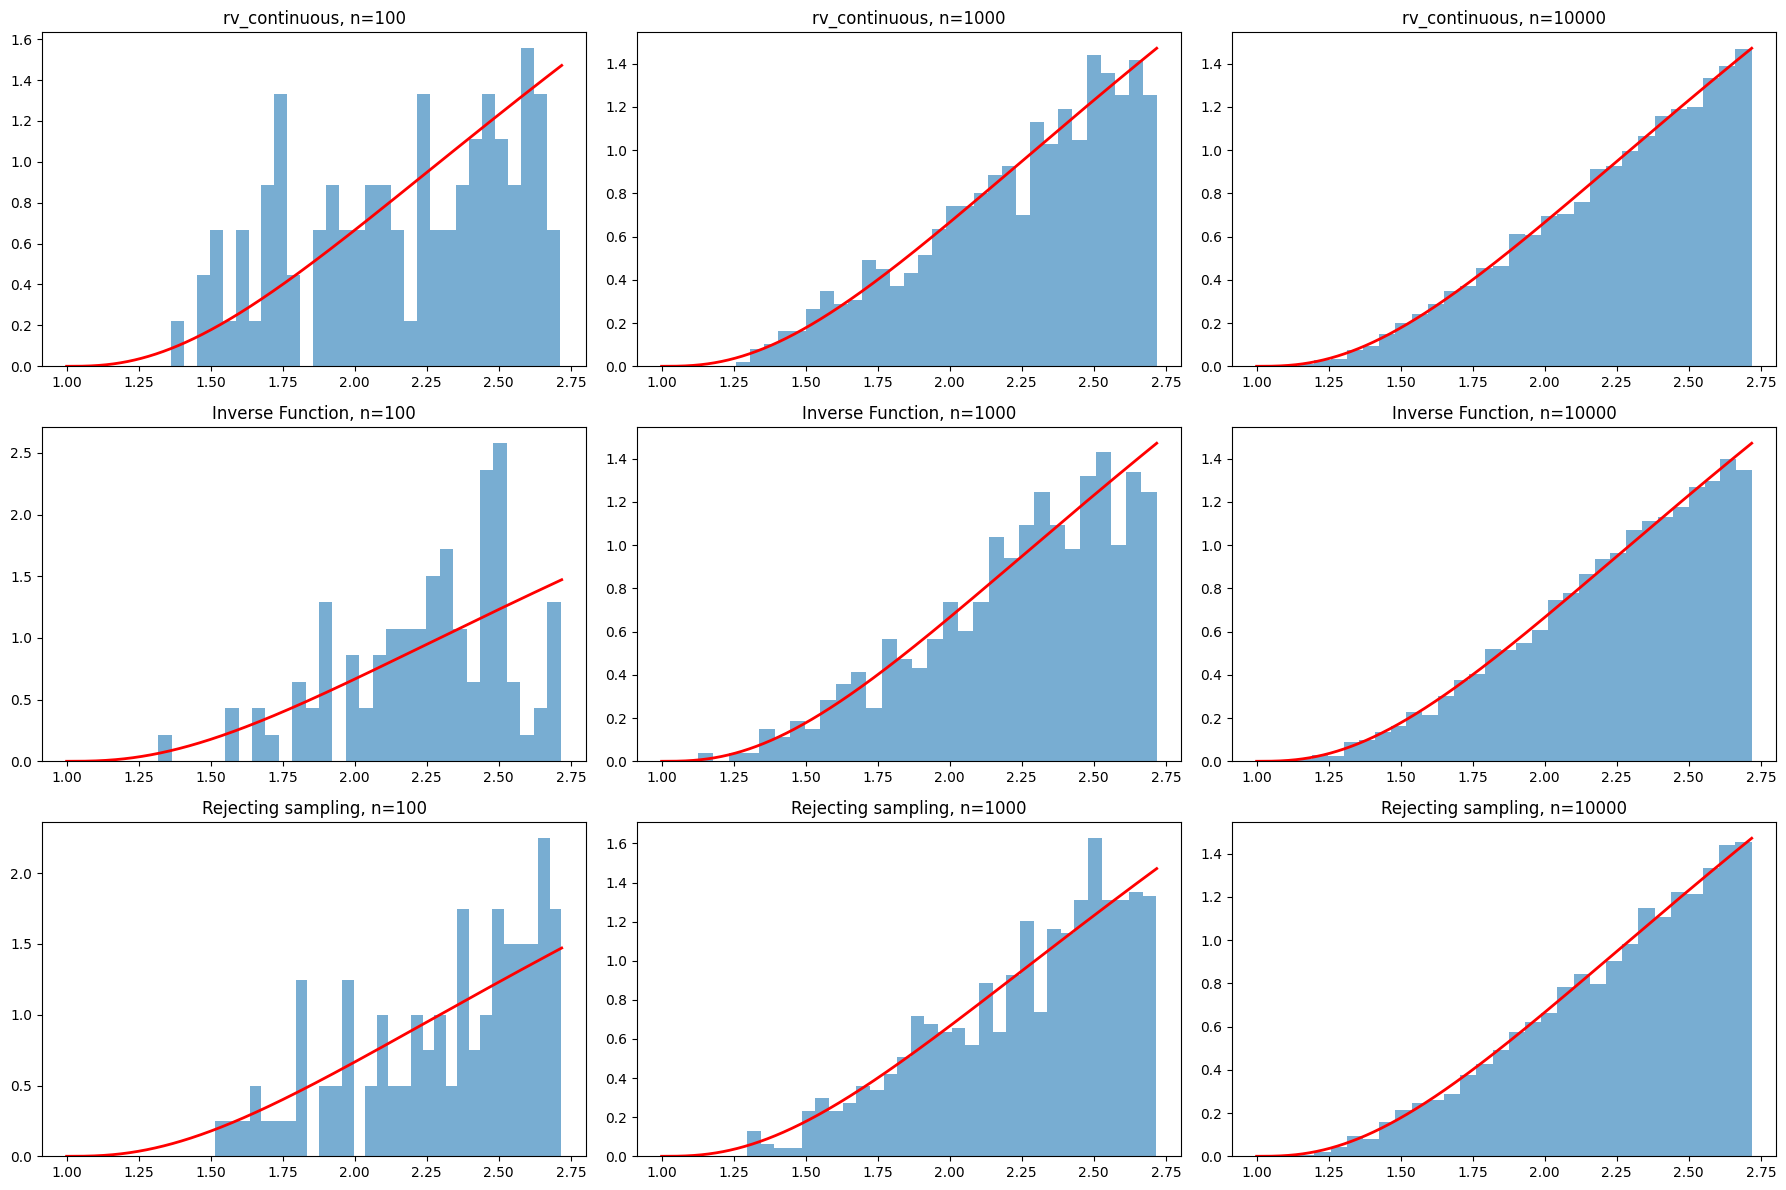

In [ ]:
x = np.linspace(1, np.e, 1000)
pdf = distr.pdf(x)
selected_n = [100, 1000, 10000]
methods = [samples1, samples2, samples3]
method_names = ["rv_continuous", "Inverse Function", "Rejecting sampling"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for i, (method, name) in enumerate(zip(methods, method_names)):
    for j, n in enumerate(selected_n):
        data = method[:n]
        ax = axes[i, j]
        ax.hist(data, bins=30, density=True, alpha=0.6)
        ax.plot(x, pdf, "r-", lw=2)
        ax.set_title(f"{name}, n={n}")

plt.tight_layout()
plt.show()

In [ ]:
def compute_kl_divergence(data, bins=30):
    hist, bin_edges = np.histogram(data, bins=bins, density=True)
    theoretical_probs = []
    for i in range(len(bin_edges) - 1):
        lower, upper = bin_edges[i], bin_edges[i + 1]
        integral, _ = quad(distr.pdf, lower, upper)
        theoretical_probs.append(integral)

    theoretical_probs = np.array(theoretical_probs) / np.sum(theoretical_probs)
    hist = hist / np.sum(hist)
    return np.sum(rel_entr(hist, theoretical_probs))

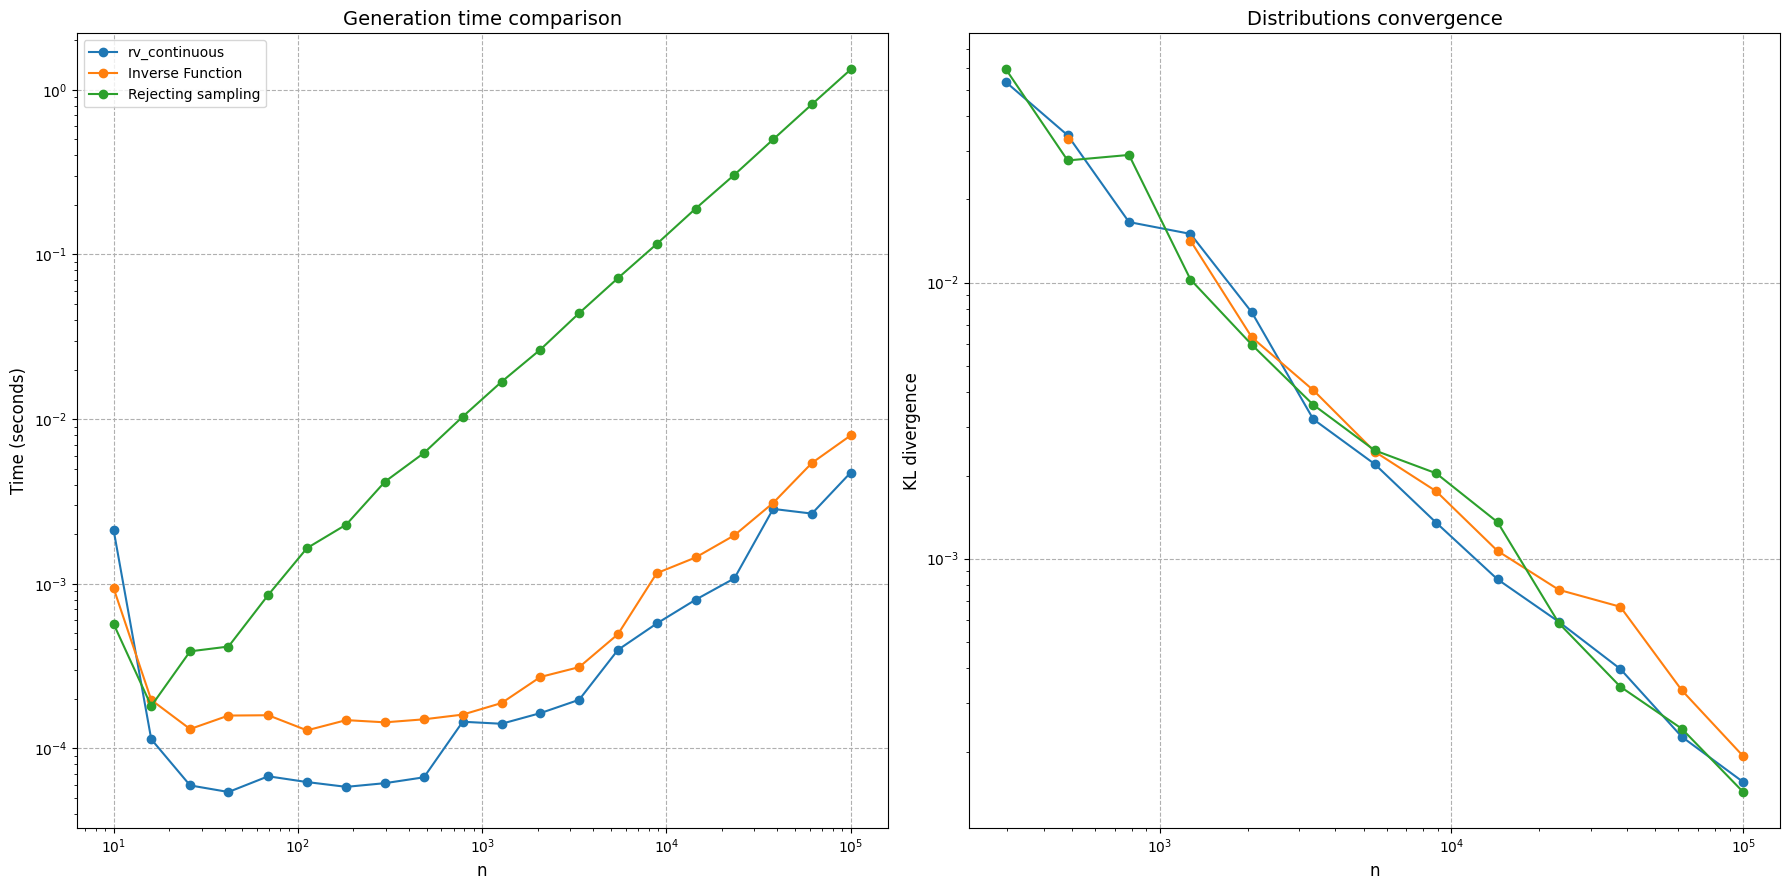

In [ ]:
kl_results = {name: [] for name in method_names}
for method, name in zip(methods, method_names):
    for n in n_values:
        data = method[:n]
        kl = compute_kl_divergence(data)
        kl_results[name].append(kl)
times = [times1, times2, times3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

for timez, name in zip(times, method_names):
    ax1.plot(n_values, timez, "o-", label=name)
    ax1.set_xscale("log")
    ax1.set_yscale("log")

ax1.set_xlabel("n", fontsize=12)
ax1.set_ylabel("Time (seconds)", fontsize=12)
ax1.set_title("Generation time comparison", fontsize=14)
ax1.grid(True, linestyle="--")
ax1.legend()

for name in method_names:
    ax2.plot(n_values, kl_results[name], "o-", label=name)
    ax2.set_xscale("log")
    ax2.set_yscale("log")

ax2.set_xlabel("n", fontsize=12)
ax2.set_ylabel("KL divergence", fontsize=12)
ax2.set_title("Distributions convergence", fontsize=14)
ax2.grid(True, linestyle="--")

plt.tight_layout()
plt.show()

In [2]:
def check_coverage(n, lam, epsilon=0.01, num_samples=100):
    coverage = 0
    for _ in range(num_samples):
        sample = np.random.poisson(lam=lam, size=n)
        sample_mean = sample.mean()
        if abs(sample_mean - lam) <= epsilon:
            coverage += 1
    return coverage / num_samples

In [ ]:
epsilon, delta, lambda_ = 0.01, 0.05, 10
n_values = [2000000, 384160, 737776]

results = {}
for n in n_values:
    print(
        f"n = {n}: доля выборок с |X̄ - 10| ≤ 0.01 = {check_coverage(n, lambda_, epsilon):.3f}"
    )

n = 2000000: доля выборок с |X̄ - 10| ≤ 0.01 = 1.000
n = 384160: доля выборок с |X̄ - 10| ≤ 0.01 = 0.940
n = 737776: доля выборок с |X̄ - 10| ≤ 0.01 = 0.980
